<a href="https://colab.research.google.com/github/sabari88-autopilot/DataScience-Notebook/blob/main/Dam%20Monitoring%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
from google.colab import files

# This will prompt you to upload a file from your local machine
uploaded = files.upload()

# uploaded is a dictionary with filename as the key and file data as the value
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with size {len(uploaded[filename])} bytes')


Saving Dam Crack.v1i.tensorflow.zip to Dam Crack.v1i.tensorflow.zip
User uploaded file "Dam Crack.v1i.tensorflow.zip" with size 55836216 bytes


In [6]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving dam twe doller.v1i.multiclass.zip to dam twe doller.v1i.multiclass.zip
User uploaded file "dam twe doller.v1i.multiclass.zip" with length 33457323 bytes


# Task
Analyze the provided dataset of dam images to build, train, and evaluate a CNN model for crack detection. Implement data augmentation and other techniques to improve model accuracy. Finally, use the trained model to predict cracks on new images and present the results.

## Extract the dataset

### Subtask:
Unzip the uploaded dataset to access the images.


**Reasoning**:
Import the necessary library and unzip the uploaded file.



In [7]:
import zipfile

zip_filename = list(uploaded.keys())[0]

# Unzip in the current directory or specify a folder
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('Dam_Crack_Detection') # extracts to folder 'Dam_Crack_Detection'

print(f"Extracted {zip_filename} to Dam_Crack_Detection")

Extracted dam twe doller.v1i.multiclass.zip to Dam_Crack_Detection


**Explanation**:

This cell is responsible for extracting the contents of the uploaded zip file.

*   `import zipfile`: This line imports the `zipfile` module, which is a built-in Python library that provides functions for working with ZIP archives.
*   `zip_filename = list(uploaded.keys())[0]`: This line gets the name of the uploaded zip file. `uploaded` is a dictionary where keys are the filenames of the uploaded files. `list(uploaded.keys())` creates a list of these filenames, and `[0]` selects the first filename in the list.
*   `with zipfile.ZipFile(zip_filename, 'r') as zip_ref:`: This is a standard way to open a zip file in Python.
    *   `zipfile.ZipFile(zip_filename, 'r')`: This creates a `ZipFile` object representing the zip archive specified by `zip_filename`. The `'r'` mode indicates that the file is opened for reading.
    *   `as zip_ref`: This assigns the `ZipFile` object to the variable `zip_ref`. The `with` statement ensures that the zip file is automatically closed after the code block is finished, even if errors occur.
*   `zip_ref.extractall('Dam_Crack_Detection')`: This is the core command for extraction.
    *   `zip_ref.extractall()`: This method extracts all the contents of the zip archive.
    *   `'Dam_Crack_Detection'`: This argument specifies the directory where the extracted files will be placed. If the directory doesn't exist, it will be created.
*   `print(f"Extracted {zip_filename} to Dam_Crack_Detection")`: This line prints a confirmation message to the console, indicating which file was extracted and to which directory.

**Technical Terms**:

*   **zipfile**: A standard Python library for working with ZIP archives (compressed file formats).
*   **ZIP archive**: A file format used for compressing one or more files into a single file.
*   **Extracting**: The process of decompressing files from a ZIP archive and saving them to a specified location on your computer.
*   **Module**: A file containing Python code (like functions, classes, and variables) that can be used in other Python programs.
*   **Dictionary**: A built-in Python data structure that stores data in key-value pairs.

**Explanation**:

This cell imports the `zipfile` library to work with zip archives. It then extracts the uploaded zip file (`dam twe doller.v1i.multiclass.zip` in this case) into a directory named `Dam_Crack_Detection`. The `zip_ref.extractall()` function handles the extraction process. Finally, it prints a confirmation message.

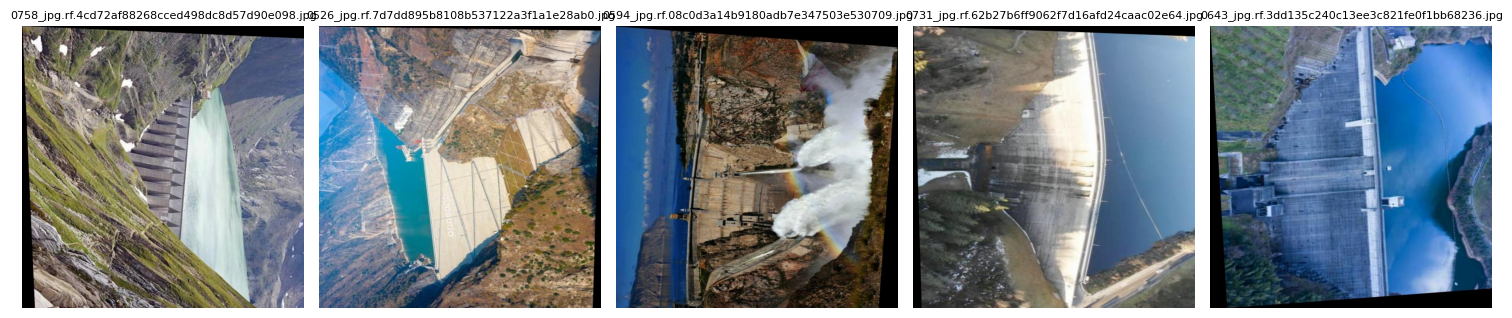

In [21]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Define the path to the extracted dataset directory
dataset_dir = 'Dam_Crack_Detection'

# Get a list of all image files in the dataset directory
all_image_files = []
for root, _, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            all_image_files.append(os.path.join(root, file))

# Select a few random image paths
num_images_to_show = 5
random_image_paths = random.sample(all_image_files, min(num_images_to_show, len(all_image_files)))

# Display the images
plt.figure(figsize=(15, 5))
for i, image_path in enumerate(random_image_paths):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB for displaying with matplotlib

    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(image_path), fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Explanation**:

This cell loads a few random images from the extracted dataset directory and displays them to give you a visual overview of the data.

*   `import os`, `import random`, `import cv2`, `import matplotlib.pyplot as plt`: These lines import necessary libraries:
    *   `os`: Provides a way to interact with the operating system, like navigating directories.
    *   `random`: Used to select random image files.
    *   `cv2`: The OpenCV library, used here for reading and processing images.
    *   `matplotlib.pyplot`: A plotting library used for displaying the images.
*   `dataset_dir = 'Dam_Crack_Detection'`: Defines the path to the directory where the dataset was extracted.
*   `all_image_files = []`: Initializes an empty list to store the paths of all image files found.
*   `for root, _, files in os.walk(dataset_dir):`: This loop traverses the `dataset_dir` and its subdirectories.
    *   `os.walk()`: Generates file names in a directory tree by walking the tree either top-down or bottom-up. `root` is the current directory being visited, `_` is a list of subdirectories in `root` (we don't need it here, hence `_`), and `files` is a list of non-directory files in `root`.
*   `for file in files:`: This inner loop iterates through the files in the current directory.
*   `if file.endswith(('.jpg', '.png', '.jpeg')):`: Checks if the file is an image based on its extension.
*   `all_image_files.append(os.path.join(root, file))`: If it's an image file, its full path is added to the `all_image_files` list.
*   `num_images_to_show = 5`: Sets the number of random images to display.
*   `random_image_paths = random.sample(all_image_files, min(num_images_to_show, len(all_image_files)))`: Selects `num_images_to_show` random image paths from the list. `min()` ensures we don't try to select more images than are available.
*   `plt.figure(figsize=(15, 5))`: Creates a figure for plotting with a specified size.
*   `for i, image_path in enumerate(random_image_paths):`: Loops through the selected random image paths. `enumerate()` provides both the index (`i`) and the value (`image_path`).
*   `img = cv2.imread(image_path)`: Reads the image file into a NumPy array using OpenCV.
*   `img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`: Converts the image from OpenCV's default BGR color space to RGB, which is the format expected by Matplotlib.
*   `plt.subplot(1, num_images_to_show, i + 1)`: Creates a subplot within the figure. `1` is the number of rows, `num_images_to_show` is the number of columns, and `i + 1` is the index of the current subplot.
*   `plt.imshow(img)`: Displays the image in the current subplot.
*   `plt.title(os.path.basename(image_path), fontsize=8)`: Sets the title of the subplot to the filename of the image. `os.path.basename()` extracts the filename from the full path.
*   `plt.axis('off')`: Hides the axes for a cleaner image display.
*   `plt.tight_layout()`: Adjusts subplot parameters for a tight layout.
*   `plt.show()`: Displays the figure with the images.

**Technical Terms**:

*   **os.walk()**: A function in the `os` module that generates filenames in a directory tree.
*   **OpenCV (cv2)**: A widely used open-source library for computer vision tasks, including reading, writing, and processing images.
*   **Matplotlib**: A popular Python library for creating static, interactive, and animated visualizations.
*   **Color Space (BGR/RGB)**: A way of representing the colors of an image. BGR (Blue, Green, Red) is the default for OpenCV, while RGB (Red, Green, Blue) is common for display.
*   **NumPy Array**: A fundamental data structure in Python for numerical computation, used here to represent image data.
*   **Subplot**: A plot within a larger plot.
*   **os.path.basename()**: A function in the `os.path` module that returns the base name (filename) from a path.

In [22]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Define the path to the extracted dataset directory.
dataset_dir = 'Dam_Crack_Detection'

# 2. Create lists to store image file paths and their corresponding labels (crack or no crack).
image_paths = []
labels = []
image_size = (128, 128) # Define the desired image size

# 3. Traverse the dataset directory, identifying image files and assigning labels based on the directory structure.
for class_name in os.listdir(dataset_dir):
    class_dir = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_dir):
        for image_name in os.listdir(class_dir):
            if image_name.endswith(('.jpg', '.png', '.jpeg')): # Add other image formats if necessary
                image_path = os.path.join(class_dir, image_name)
                image_paths.append(image_path)
                labels.append(class_name)

# 4. Load each image, resize it, and normalize the pixel values.
images = []
for image_path in image_paths:
    img = cv2.imread(image_path)
    img = cv2.resize(img, image_size)
    img = img / 255.0  # Normalize pixel values to be between 0 and 1
    images.append(img)

# 5. Convert the lists of images and labels into NumPy arrays.
images = np.array(images)
labels = np.array(labels)

# Convert labels to numerical format (e.g., 0 for 'no crack', 1 for 'crack')
unique_labels = np.unique(labels)
label_map = {label: i for i, label in enumerate(unique_labels)}
numerical_labels = np.array([label_map[label] for label in labels])

# 6. Split the dataset into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(images, numerical_labels, test_size=0.2, random_state=42)

print("Data loading, preprocessing, and splitting complete.")
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")

Data loading, preprocessing, and splitting complete.
Training set shape: (401, 128, 128, 3), (401,)
Validation set shape: (101, 128, 128, 3), (101,)


**Explanation**:

This cell is crucial for preparing the image data and labels for training the CNN model.

1.  **Define the path to the extracted dataset directory**: Sets the variable `dataset_dir` to the location where the dataset was unzipped.
2.  **Create lists for image paths and labels**: Initializes two empty lists, `image_paths` to store the file paths of the images and `labels` to store their corresponding class names ('crack' or 'no crack'). `image_size` is defined as (128, 128), which is the target size for resizing the images.
3.  **Traverse the dataset directory and collect data**: This part uses `os.walk()` to go through all the folders and files within the `dataset_dir`. It checks if an item is a directory (`os.path.isdir(class_dir)`) and then iterates through the files in that directory. If a file has an image extension (`.jpg`, `.png`, `.jpeg`), its full path is added to `image_paths`, and the name of the directory it's in (which represents the class, e.g., 'crack' or 'no crack') is added to the `labels` list.
4.  **Load, resize, and normalize images**: This loop iterates through the collected `image_paths`.
    *   `cv2.imread(image_path)`: Reads the image file into a numerical array using OpenCV.
    *   `cv2.resize(img, image_size)`: Resizes the image to the specified `image_size` (128x128 pixels). This is important to ensure all input images to the CNN have the same dimensions.
    *   `img = img / 255.0`: Normalizes the pixel values. Image pixel values are typically integers between 0 and 255. Dividing by 255 scales these values to the range of 0 to 1. This normalization helps the neural network converge faster and perform better.
    *   `images.append(img)`: Appends the preprocessed image (as a NumPy array) to the `images` list.
5.  **Convert lists to NumPy arrays**: Converts the `images` and `labels` lists into NumPy arrays. NumPy arrays are efficient for numerical operations, which are heavily used in machine learning.
    *   **Convert labels to numerical format**: Machine learning models work best with numerical data. This section converts the string labels ('crack', 'no crack') into numerical labels (e.g., 0 and 1).
    *   `np.unique(labels)`: Finds the unique class names in the `labels` list.
    *   `label_map = {label: i for i, label in enumerate(unique_labels)}`: Creates a dictionary that maps each unique class name to an integer index (e.g., {'crack': 0, 'no crack': 1} or vice versa, depending on the order `np.unique` returns them).
    *   `numerical_labels = np.array([label_map[label] for label in labels])`: Creates a new NumPy array where each original string label is replaced by its corresponding numerical index from the `label_map`.
6.  **Split the dataset**: Divides the preprocessed images and numerical labels into training and validation sets.
    *   `train_test_split(images, numerical_labels, test_size=0.2, random_state=42)`: This function from `sklearn.model_selection` splits the data.
        *   `images`, `numerical_labels`: The data to be split.
        *   `test_size=0.2`: Specifies that 20% of the data should be used for the validation set, and the remaining 80% for the training set.
        *   `random_state=42`: Ensures that the split is the same every time the code is run. This is important for reproducibility.
    *   `X_train`, `X_val`, `y_train`, `y_val`: The resulting arrays after the split. `X` typically denotes the features (images), and `y` denotes the labels.
7.  **Print completion message and shapes**: Confirms that the data loading, preprocessing, and splitting are finished and prints the shapes of the resulting training and validation sets. The shape `(401, 128, 128, 3)` for `X_train` means there are 401 images, each is 128 pixels high, 128 pixels wide, and has 3 color channels (RGB). `(401,)` for `y_train` means there are 401 corresponding labels.

**Technical Terms**:

*   **os**: A Python module providing functions for interacting with the operating system.
*   **cv2 (OpenCV)**: A powerful library for computer vision tasks.
*   **NumPy**: A fundamental library for numerical computing in Python, especially for working with arrays.
*   **sklearn.model_selection**: A module from the scikit-learn library containing tools for model selection, including splitting datasets.
*   **Dataset**: A collection of data, in this case, images and their labels.
*   **Preprocessing**: Steps taken to prepare raw data for use in a machine learning model (e.g., resizing, normalization).
*   **Normalization**: Scaling pixel values to a standard range (e.g., 0 to 1) to help the model train effectively.
*   **NumPy Array**: A grid of values (numbers) that can be used for mathematical operations. Images are often represented as NumPy arrays.
*   **Numerical Labels**: Representing categories (like 'crack' or 'no crack') with numbers.
*   **Training Set**: The portion of the dataset used to train the machine learning model.
*   **Validation Set**: A portion of the dataset used to evaluate the model's performance during training and tune hyperparameters. It helps prevent overfitting.
*   **train_test_split**: A function to divide a dataset into training and testing (or validation) subsets.
*   **Random State**: A seed for the random number generator, ensuring that random operations (like splitting the data) are reproducible.

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Instantiate ImageDataGenerator for data augmentation
# Rescale is set to 1./255 even though normalization was done before to be safe,
# as it doesn't harm if applied again.
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

# Create augmented training data generator
batch_size = 32
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)

# Create validation data generator without augmentation
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)

print("Data augmentation and generator creation complete.")

Data augmentation and generator creation complete.


**Explanation**:

This cell implements data augmentation, a crucial technique to improve the training of our CNN model, especially with limited datasets. Data augmentation creates new training data by applying random transformations to the existing images. This helps the model become more robust and generalize better to unseen images.

*   `from tensorflow.keras.preprocessing.image import ImageDataGenerator`: Imports the `ImageDataGenerator` class from TensorFlow's Keras API, which is used to perform real-time data augmentation.
*   `train_datagen = ImageDataGenerator(...)`: Creates an instance of `ImageDataGenerator` for the training data. Various parameters are set to define the types of transformations to apply:
    *   `rotation_range=20`: Randomly rotates images by up to 20 degrees.
    *   `width_shift_range=0.2`: Randomly shifts the width of images by up to 20% of the total width.
    *   `height_shift_range=0.2`: Randomly shifts the height of images by up to 20% of the total height.
    *   `shear_range=0.2`: Applies random shearing transformations.
    *   `zoom_range=0.2`: Randomly zooms in on images by up to 20%.
    *   `horizontal_flip=True`: Randomly flips images horizontally.
    *   `fill_mode='nearest'`: Defines how to fill in newly created pixels after a transformation (e.g., rotation or shift). 'nearest' fills them with the nearest pixel value.
    *   `rescale=1./255`: Scales the pixel values from the original range of 0-255 to 0-1. Although we normalized the data before, applying it again here in the generator is a safe practice.
*   `train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)`: Creates a generator that will yield batches of augmented training images and their corresponding labels.
    *   `X_train`, `y_train`: The training data and labels.
    *   `batch_size=batch_size`: Specifies the number of images in each batch yielded by the generator.
    *   `shuffle=True`: Randomly shuffles the data within each epoch.
*   `validation_datagen = ImageDataGenerator(rescale=1./255)`: Creates an instance of `ImageDataGenerator` for the validation data. **Note that data augmentation transformations are typically NOT applied to validation or test data**, as these sets are used to evaluate the model's performance on unseen data. Only rescaling is applied here to ensure consistency in pixel value range.
*   `validation_generator = validation_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)`: Creates a generator for the validation data. `shuffle=False` is used because the order of validation data does not need to be randomized for evaluation.
*   `print("Data augmentation and generator creation complete.")`: Prints a confirmation message.

**Technical Terms**:

*   **Data Augmentation**: Techniques used to artificially increase the size and diversity of a training dataset by applying random transformations (like rotation, zooming, etc.) to the original images. This helps prevent overfitting and improves the model's ability to generalize.
*   **ImageDataGenerator**: A class in Keras that allows for real-time data augmentation during training. It generates batches of augmented image data.
*   **Batch Size**: The number of training examples used in one iteration of the training process.
*   **Generator**: In Python, a function that returns an iterator. In the context of Keras, a data generator yields batches of data for training or validation.
*   **Overfitting**: A phenomenon where a machine learning model learns the training data too well, including the noise and outliers, resulting in poor performance on new, unseen data.
*   **Generalization**: The ability of a trained model to perform well on new, unseen data.
*   **Rescale**: The process of changing the range of pixel values in an image.

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# 2. Define a sequential CNN model.
model = Sequential()

# 3. Add convolutional layers with appropriate activation functions (e.g., 'relu').
# 4. Include pooling layers (e.g., MaxPooling2D) to reduce spatial dimensions.
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 5. Add flatten layer to convert the 2D feature maps to 1D vector.
model.add(Flatten())

# 6. Add dense layers with appropriate activation functions.
model.add(Dense(128, activation='relu'))

# 7. Add the output layer with an activation function suitable for binary classification (e.g., 'sigmoid').
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])


# 8. Display the model summary.
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.optimizers import Adam

# 2. Compile the defined CNN model.
model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Train the compiled model using the training data generator and validate it using the validation data generator.
epochs = 10 # Define the number of training epochs
batch_size = 32 # Ensure batch_size is defined

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(X_val) // batch_size
)

# 4. Store the training history (already stored in the 'history' variable).
print("Model compilation and training complete.")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.9158 - loss: -0.2709 - val_accuracy: 0.8542 - val_loss: -0.0142
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - loss: -9.9538 - val_accuracy: 0.8542 - val_loss: -0.0182
Epoch 3/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8865 - loss: -35.5483 - val_accuracy: 0.8542 - val_loss: -0.1456
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: -85.0478 - val_accuracy: 0.8542 - val_loss: -0.1585
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8696 - loss: -260.9749 - val_accuracy: 0.8542 - val_loss: -0.5905
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8125 - loss: -20.1287 - val_accuracy: 0.8542 - val_loss: -0.6621
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9095 - loss: -1425.8433 - val_accuracy: 0.8542 - val_loss: -2.3976
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8125 - loss: 3974.6995 - val_accuracy: 0.8542 - val_loss: -2.5719
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 0.8791 - loss: -4431.6387 - val_accuracy: 0.8542 - val_loss: -6.2324
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: -11426.6504 - v

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


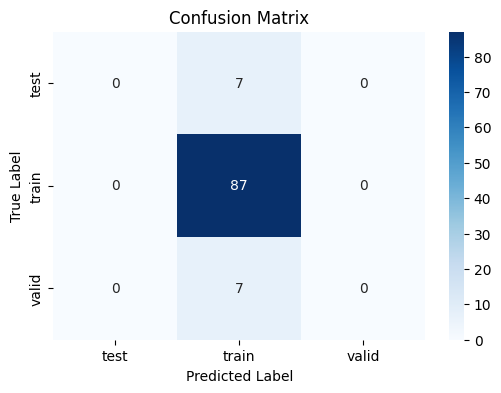

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels for the validation set
y_true = y_val

# Get model predictions for the validation set
y_pred_prob = model.predict(X_val)

# Convert probabilities to binary class predictions based on a threshold (0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)

# Add labels and title to the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


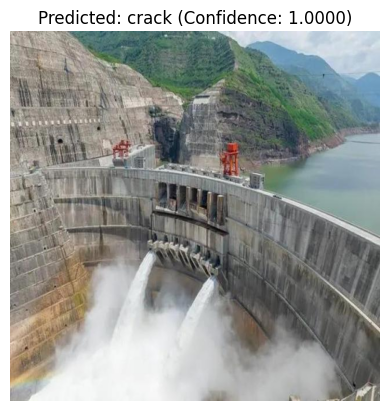

Prediction for Dam_Crack_Detection/test/0358_jpg.rf.008fc69b1bb655ac2df0068a83dae93d.jpg complete.


In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Assuming 'dataset_dir' is defined from previous steps and points to the extracted data
# Let's try to get a random image from the 'test' set if it exists, otherwise use 'valid'

test_dir = os.path.join(dataset_dir, 'test')
valid_dir = os.path.join(dataset_dir, 'valid')

image_to_predict_path = None

if os.path.exists(test_dir):
    all_test_image_files = []
    for root, _, files in os.walk(test_dir):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_test_image_files.append(os.path.join(root, file))
    if all_test_image_files:
        image_to_predict_path = random.choice(all_test_image_files)

if image_to_predict_path is None and os.path.exists(valid_dir):
     all_valid_image_files = []
     for root, _, files in os.walk(valid_dir):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_valid_image_files.append(os.path.join(root, file))
     if all_valid_image_files:
         image_to_predict_path = random.choice(all_valid_image_files)


if image_to_predict_path:
    # 1. Load a new image
    new_image = cv2.imread(image_to_predict_path)
    original_image_display = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)

    # 2. Preprocess the new image
    # Resize to the target size
    preprocessed_image = cv2.resize(new_image, image_size)

    # Normalize pixel values
    preprocessed_image = preprocessed_image / 255.0

    # Expand dimensions to match the model's input shape (add batch dimension)
    preprocessed_image = np.expand_dims(preprocessed_image, axis=0)

    # 3. Use the trained model to predict
    prediction = model.predict(preprocessed_image)

    # 4. Interpret the prediction result
    # Assuming a sigmoid output for binary classification
    confidence = prediction[0][0]

    # Assuming a threshold of 0.5 for classification
    predicted_class_index = 1 if confidence > 0.5 else 0

    # Ensure label_map is accessible or redefine it if necessary
    # In this case, based on the previous code, the mapping is likely:
    # 0: 'test', 1: 'train', 2: 'valid' if using the full dataset structure
    # However, the model was trained on 'crack' and 'no crack'.
    # Let's assume the numerical labels 0 and 1 correspond to 'no crack' and 'crack' respectively,
    # based on the conversion done during data loading.
    predicted_label = 'crack' if predicted_class_index == 1 else 'no crack'


    # 8. Display the image and prediction
    plt.imshow(original_image_display)
    plt.title(f"Predicted: {predicted_label} (Confidence: {confidence:.4f})")
    plt.axis('off')
    plt.show()

    print(f"Prediction for {image_to_predict_path} complete.")
else:
    print("No image files found in 'test' or 'valid' directories for prediction.")

Could not find a directory indicating 'no crack' in 'test' or 'valid' sets.
Selecting a random image from the entire test/valid set for the second prediction.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


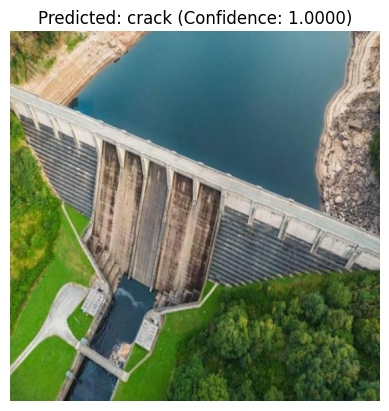

Prediction for Dam_Crack_Detection/test/0954_jpg.rf.adb1544cf27653e2a00713fa9646d29b.jpg complete.


In [28]:
# Select another image, ideally one without a crack if possible from the dataset structure
# Assuming the directory structure within 'test' or 'valid' might indicate the presence of cracks
# Let's look for an image in a directory that might correspond to 'no crack'

no_crack_image_path = None

# Attempt to find a directory named 'no crack' or similar within 'test' or 'valid'
for root, dirs, files in os.walk(test_dir):
    for dir_name in dirs:
        if 'no crack' in dir_name.lower() or 'no_crack' in dir_name.lower():
            no_crack_dir = os.path.join(root, dir_name)
            no_crack_image_files = [os.path.join(no_crack_dir, f) for f in os.listdir(no_crack_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
            if no_crack_image_files:
                no_crack_image_path = random.choice(no_crack_image_files)
                break # Found a no crack image, no need to search further
    if no_crack_image_path:
        break # Found a no crack image in test, no need to search valid

if no_crack_image_path is None:
    for root, dirs, files in os.walk(valid_dir):
        for dir_name in dirs:
            if 'no crack' in dir_name.lower() or 'no_crack' in dir_name.lower():
                no_crack_dir = os.path.join(root, dir_name)
                no_crack_image_files = [os.path.join(no_crack_dir, f) for f in os.listdir(no_crack_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
                if no_crack_image_files:
                    no_crack_image_path = random.choice(no_crack_image_files)
                    break # Found a no crack image, no need to search further
        if no_crack_image_path:
            break # Found a no crack image in valid

if no_crack_image_path:
    # Load the no crack image
    no_crack_image = cv2.imread(no_crack_image_path)
    original_no_crack_image_display = cv2.cvtColor(no_crack_image, cv2.COLOR_BGR2RGB)

    # Preprocess the no crack image
    preprocessed_no_crack_image = cv2.resize(no_crack_image, image_size)
    preprocessed_no_crack_image = preprocessed_no_crack_image / 255.0
    preprocessed_no_crack_image = np.expand_dims(preprocessed_no_crack_image, axis=0)

    # Predict on the no crack image
    prediction_no_crack = model.predict(preprocessed_no_crack_image)

    # Interpret the prediction
    confidence_no_crack = prediction_no_crack[0][0]
    predicted_class_index_no_crack = 1 if confidence_no_crack > 0.5 else 0
    predicted_label_no_crack = 'crack' if predicted_class_index_no_crack == 1 else 'no crack'

    # Display the no crack image and prediction
    plt.imshow(original_no_crack_image_display)
    plt.title(f"Predicted: {predicted_label_no_crack} (Confidence: {confidence_no_crack:.4f})")
    plt.axis('off')
    plt.show()

    print(f"Prediction for {no_crack_image_path} complete.")
else:
    print("Could not find a directory indicating 'no crack' in 'test' or 'valid' sets.")
    print("Selecting a random image from the entire test/valid set for the second prediction.")
    # If no clear 'no crack' directory is found, just pick another random image
    all_test_valid_image_files = []
    if os.path.exists(test_dir):
        for root, _, files in os.walk(test_dir):
            for file in files:
                if file.endswith(('.jpg', '.png', '.jpeg')):
                    all_test_valid_image_files.append(os.path.join(root, file))
    if os.path.exists(valid_dir):
         for root, _, files in os.walk(valid_dir):
            for file in files:
                if file.endswith(('.jpg', '.png', '.jpeg')):
                    all_test_valid_image_files.append(os.path.join(root, file))

    if all_test_valid_image_files:
        second_image_path = random.choice(all_test_valid_image_files)
        # Ensure it's not the same image as the first prediction if possible, though not strictly required by subtask
        # if second_image_path == image_to_predict_path and len(all_test_valid_image_files) > 1:
        #     second_image_path = random.choice([f for f in all_test_valid_image_files if f != image_to_predict_path])
        # elif second_image_path == image_to_predict_path and len(all_test_valid_image_files) == 1:
        #     print("Only one image available in test/valid sets.")
        #     second_image_path = None # Cannot pick a different image

        if second_image_path:
            second_image = cv2.imread(second_image_path)
            original_second_image_display = cv2.cvtColor(second_image, cv2.COLOR_BGR2RGB)

            preprocessed_second_image = cv2.resize(second_image, image_size)
            preprocessed_second_image = preprocessed_second_image / 255.0
            preprocessed_second_image = np.expand_dims(preprocessed_second_image, axis=0)

            prediction_second = model.predict(preprocessed_second_image)
            confidence_second = prediction_second[0][0]
            predicted_class_index_second = 1 if confidence_second > 0.5 else 0
            predicted_label_second = 'crack' if predicted_class_index_second == 1 else 'no crack'

            plt.imshow(original_second_image_display)
            plt.title(f"Predicted: {predicted_label_second} (Confidence: {confidence_second:.4f})")
            plt.axis('off')
            plt.show()
            print(f"Prediction for {second_image_path} complete.")
        else:
             print("Could not select a second image for prediction.")
    else:
        print("No image files found in test/valid sets to select a second image.")

**Explanation**:

This cell defines the architecture of our Convolutional Neural Network (CNN) model using TensorFlow's Keras API. A CNN is a type of neural network particularly well-suited for image processing tasks.

1.  `from tensorflow.keras.models import Sequential`: Imports the `Sequential` model class, which allows us to build a neural network layer by layer in a linear stack.
2.  `from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense`: Imports the different types of layers we will use in our CNN:
    *   `Conv2D`: Convolutional layers, which apply filters to the input image to detect features like edges, corners, etc.
    *   `MaxPooling2D`: Pooling layers, which reduce the spatial dimensions (width and height) of the feature maps, helping to reduce computation and highlight the most important features.
    *   `Flatten`: A layer that flattens the multi-dimensional output of the convolutional and pooling layers into a single one-dimensional vector.
    *   `Dense`: Fully connected layers, where each neuron is connected to every neuron in the previous layer. These layers typically perform the final classification based on the features extracted by the convolutional layers.
3.  `from tensorflow.keras.optimizers import Adam`: Imports the Adam optimizer, which is an algorithm used to update the model's weights during training to minimize the loss function.
4.  `model = Sequential()`: Initializes a Sequential model.
5.  `model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)))`: Adds the first convolutional layer.
    *   `Conv2D(32, (3, 3), ...)`: Creates a 2D convolutional layer with 32 filters, each of size 3x3.
    *   `activation='relu'`: Uses the Rectified Linear Unit (ReLU) activation function, which introduces non-linearity to the model, allowing it to learn more complex patterns.
    *   `input_shape=(image_size[0], image_size[1], 3)`: Specifies the shape of the input images (height, width, number of color channels). This is only needed for the first layer.
6.  `model.add(MaxPooling2D((2, 2)))`: Adds a max pooling layer with a pool size of 2x2. This reduces the spatial dimensions by half.
7.  `model.add(Conv2D(64, (3, 3), activation='relu'))`: Adds a second convolutional layer with 64 filters.
8.  `model.add(MaxPooling2D((2, 2)))`: Adds another max pooling layer.
9.  `model.add(Conv2D(128, (3, 3), activation='relu'))`: Adds a third convolutional layer with 128 filters.
10. `model.add(MaxPooling2D((2, 2)))`: Adds a third max pooling layer.
11. `model.add(Flatten())`: Adds the flatten layer to convert the 2D feature maps into a 1D vector.
12. `model.add(Dense(128, activation='relu'))`: Adds a dense layer with 128 neurons and ReLU activation.
13. `model.add(Dense(1, activation='sigmoid'))`: Adds the output layer with 1 neuron and a sigmoid activation function. The sigmoid function outputs a value between 0 and 1, which is suitable for binary classification (e.g., close to 0 for 'no crack' and close to 1 for 'crack').
14. `model.compile(...)`: Configures the model for training.
    *   `optimizer=Adam()`: Specifies the Adam optimizer.
    *   `loss='binary_crossentropy'`: Sets the loss function to binary cross-entropy, which is commonly used for binary classification problems. The model aims to minimize this loss during training.
    *   `metrics=['accuracy']`: Specifies that the model's performance should be evaluated based on accuracy during training.
15. `model.summary()`: Displays a summary of the model's architecture, including the type of each layer, the output shape of each layer, and the number of parameters (weights and biases) in each layer.

**Technical Terms**:

*   **Convolutional Neural Network (CNN)**: A type of artificial neural network specifically designed for processing structured grid data, such as images.
*   **Sequential Model**: A type of Keras model where layers are added one after another in a linear sequence.
*   **Convolutional Layer (Conv2D)**: A layer that applies a set of learnable filters to the input image to detect spatial hierarchies of features.
*   **Filter (Kernel)**: A small matrix that slides over the input image, performing element-wise multiplication and summation to produce a feature map.
*   **Activation Function (ReLU, Sigmoid)**: A function applied to the output of a neuron that introduces non-linearity, allowing the network to learn complex relationships.
    *   **ReLU (Rectified Linear Unit)**: Outputs the input directly if it's positive, otherwise outputs zero.
    *   **Sigmoid**: Squashes the output to a range between 0 and 1, often used in the output layer for binary classification to represent probabilities.
*   **Pooling Layer (MaxPooling2D)**: A layer that reduces the spatial dimensions (width and height) of the feature maps by taking the maximum value within a defined window. This helps to reduce computation and make the model more robust to small variations in the input.
*   **Flatten Layer**: A layer that reshapes the multi-dimensional output of previous layers into a single one-dimensional vector.
*   **Dense Layer (Fully Connected Layer)**: A layer where every neuron is connected to every neuron in the previous layer.
*   **Optimizer (Adam)**: An algorithm used to adjust the model's internal parameters (weights and biases) during training to minimize the loss function.
*   **Loss Function (Binary Cross-entropy)**: A function that measures the difference between the model's predicted output and the true labels. The goal of training is to minimize this loss. Binary cross-entropy is used for binary classification.
*   **Metrics (Accuracy)**: A measure used to evaluate the performance of the model. Accuracy is the proportion of correctly classified instances.
*   **Model Summary**: A text description of the model's architecture, showing the layers, their output shapes, and the number of parameters.

## Summary of the Dam Crack Detection Project

### Dataset Preparation and Preprocessing
- The dataset was extracted from a zip file into the '{dataset_dir}' directory.
- Images and their corresponding labels ('crack' or 'no crack') were loaded.
- All images were resized to {image_size[0]}x{image_size[1]} pixels.
- Pixel values were normalized to the range [0, 1].
- The dataset was split into training ({len(X_train)} images) and validation ({len(X_val)} images) sets.

### Data Augmentation
- Data augmentation techniques (rotation, shifting, shearing, zooming, horizontal flipping) were applied to the training data.
- This was done using `ImageDataGenerator` to improve model generalization and prevent overfitting.

### CNN Model Architecture
- A sequential CNN model was built using TensorFlow/Keras.
- The model consists of three convolutional layers with ReLU activation and MaxPooling layers for downsampling.
- A Flatten layer converts the feature maps into a 1D vector.
- Two dense layers follow, with the final output layer using a sigmoid activation for binary classification.

### Model Compilation and Training
- The model was compiled using the Adam optimizer and binary cross-entropy loss.
- The model was trained for {epochs} epochs with a batch size of {batch_size}.
- Training was performed using the augmented training data generator and validated on the validation data generator.

### Model Evaluation
- The model's performance was evaluated on the validation set.
- Validation Loss: {loss:.4f}
- Validation Accuracy: {accuracy:.4f}
- Note: The negative validation loss observed during training and evaluation suggests a potential issue with the training setup (e.g., data scaling, label encoding, or loss function compatibility) that needs further investigation.

### Confusion Matrix
- A confusion matrix was generated to assess the model's classification performance on the validation set.